# step 1

# Get the data
## 1.download the dataset
## 2.import all dependencies of your project
## 3.load the dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel('pima-data.xlsx')
df

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
0,6,148,72,35,0,33.6,0.627,50,1,1.3790,True,True
1,1,85,66,29,0,26.6,0.351,31,0,1.1426,False,False
2,8,183,64,0,0,23.3,0.672,32,1,0.0000,True,True
3,1,89,66,23,94,28.1,0.167,21,0,0.9062,False,False
4,0,137,40,35,168,43.1,2.288,33,1,1.3790,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,1.8912,False,False
764,2,122,70,27,0,36.8,0.340,27,0,1.0638,False,False
765,5,121,72,23,112,26.2,0.245,30,0,0.9062,False,False
766,1,126,60,0,0,30.1,0.349,47,1,0.0000,True,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   num_preg       768 non-null    int64  
 1   glucose_conc   768 non-null    int64  
 2   diastolic_bp   768 non-null    int64  
 3   thickness      768 non-null    int64  
 4   insulin        768 non-null    int64  
 5   bmi            768 non-null    float64
 6   diab_pred      768 non-null    float64
 7   age            768 non-null    int64  
 8   diabetes_orig  768 non-null    int64  
 9   skin           768 non-null    float64
 10  has_diabetes   768 non-null    bool   
 11  diabetes       768 non-null    bool   
dtypes: bool(2), float64(3), int64(7)
memory usage: 61.6 KB


# cleaning the dataset

In [4]:
## 1.check the null values is present or not in dataset
df.isnull()


,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
df.isnull().sum()

num_preg         0
glucose_conc     0
diastolic_bp     0
thickness        0
insulin          0
bmi              0
diab_pred        0
age              0
diabetes_orig    0
skin             0
has_diabetes     0
diabetes         0
dtype: int64

# 2. checking the correlation of your project

In [6]:
df.corr()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
num_preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898,-0.081672,0.221898,0.221898
glucose_conc,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581,0.057328,0.466581,0.466581
diastolic_bp,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068,0.207371,0.065068,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752,1.000000,0.074752,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548,0.436783,0.130548,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695,0.392573,0.292695,0.292695
diab_pred,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844,0.183928,0.173844,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356,-0.113970,0.238356,0.238356
diabetes_orig,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000,0.074752,1.000000,1.000000
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752,1.000000,0.074752,0.074752


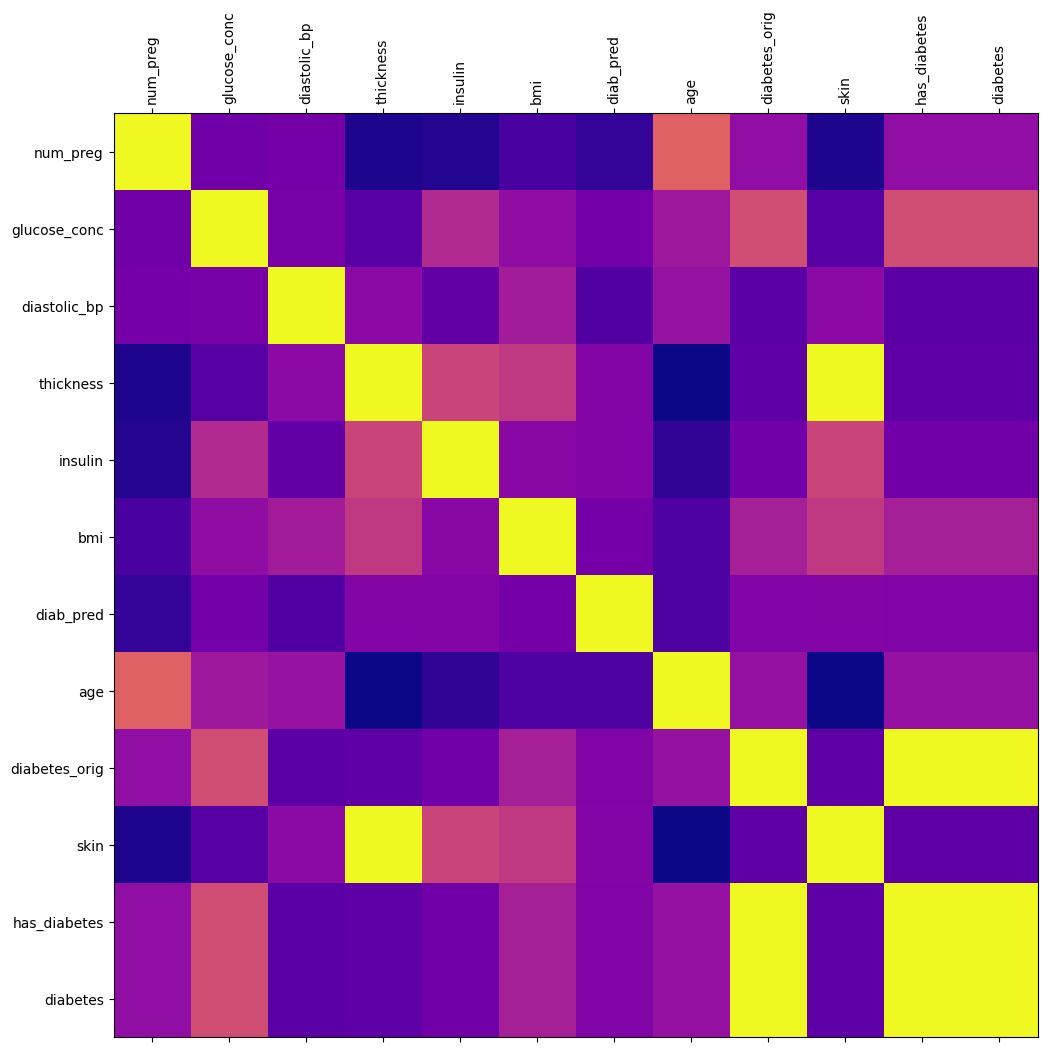

In [7]:
def check_corr(size):
    corr=df.corr()
    fig,ax=plt.subplots(figsize=(size,size))
    cmap='plasma'
    ax.matshow(corr,cmap=cmap)
    plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
    plt.yticks(range(len(corr.columns)),corr.columns)
    plt.show()
check_corr(12)

# we obeserved few columns are correlated to each other 

# 1.skin and thickness are correlated to each other
# has_diabetes and diabetes_orig are correlted
# diabetes and diabetes_orig are correlate 
# has_diabetes and diabetes
# drop the correlated columns

In [8]:
df.drop('thickness',axis=1,inplace=True)
df.drop('diabetes_orig',axis=1,inplace=True)




In [9]:
df.drop('has_diabetes',axis=1,inplace=True)

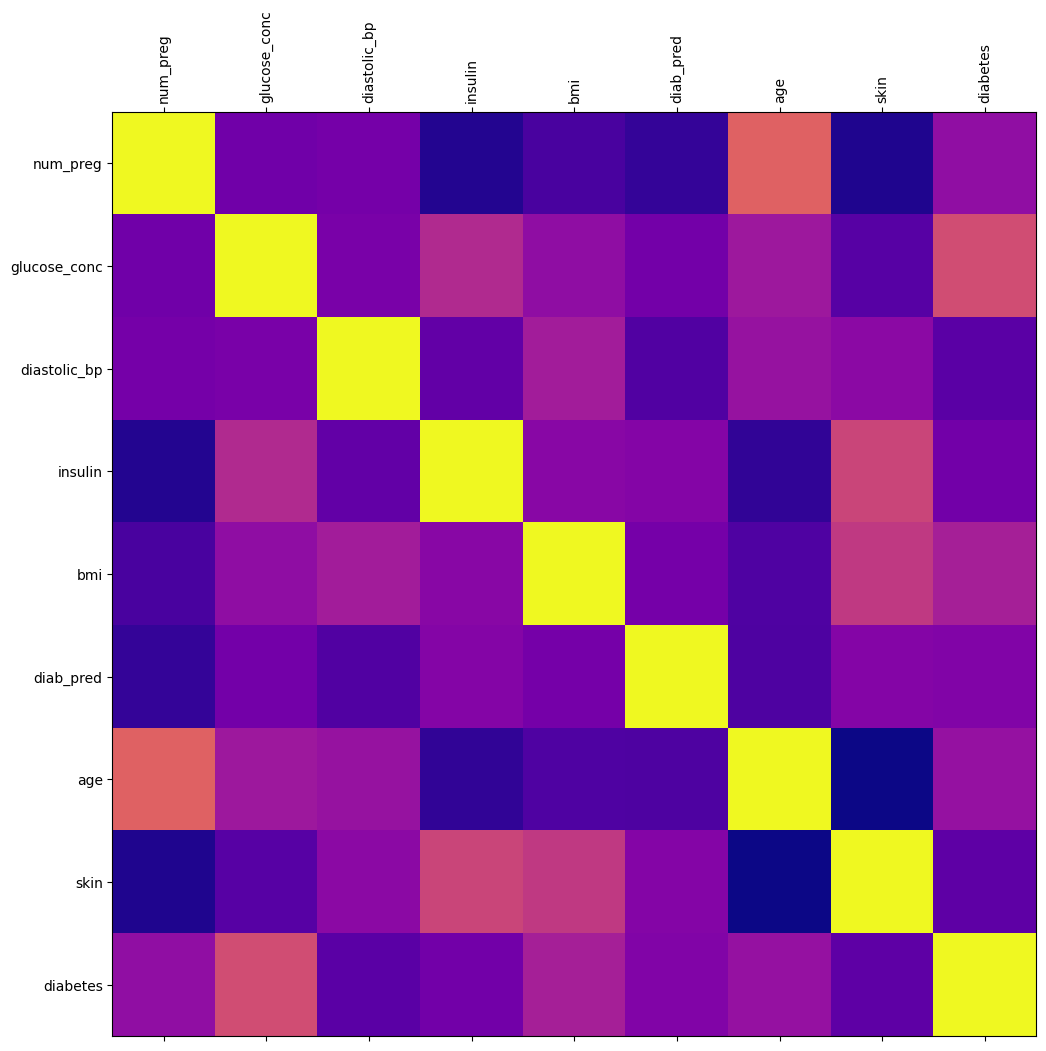

In [10]:
check_corr(12)

# 3.convert string to integer to data type

In [11]:
df.head()

,num_preg,glucose_conc,diastolic_bp,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,0,33.6,0.627,50,1.3790,True
1,1,85,66,0,26.6,0.351,31,1.1426,False
2,8,183,64,0,23.3,0.672,32,0.0000,True
3,1,89,66,94,28.1,0.167,21,0.9062,False
4,0,137,40,168,43.1,2.288,33,1.3790,True


In [12]:
df['diabetes'].unique()

array([ True, False])

In [13]:
df['diabetes']=df['diabetes'].map({True:1,False:0})

In [14]:
df.head()

,num_preg,glucose_conc,diastolic_bp,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,0,33.6,0.627,50,1.3790,1
1,1,85,66,0,26.6,0.351,31,1.1426,0
2,8,183,64,0,23.3,0.672,32,0.0000,1
3,1,89,66,94,28.1,0.167,21,0.9062,0
4,0,137,40,168,43.1,2.288,33,1.3790,1


# 4 check the proportion of data

In [15]:
num_true=len(df.loc[df['diabetes']==1])
num_false=len(df.loc[df['diabetes']==0])
print(num_true)
print(num_false)


268
500


In [16]:
true_percentage=((num_true/(num_true+num_false))*100)
false_percentage=((num_false/(num_true+num_false))*100)
print(true_percentage)

print(false_percentage)

34.89583333333333
65.10416666666666


# step 3:Train the model

# 1.Train test split

In [17]:
df.columns


Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='str')

In [18]:
input_columns=['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin']
output_columns=['diabetes']

x=df[input_columns].values
y=df[output_columns].values



In [19]:
x

array([[  6.    , 148.    ,  72.    , ...,   0.627 ,  50.    ,   1.379 ],
       [  1.    ,  85.    ,  66.    , ...,   0.351 ,  31.    ,   1.1426],
       [  8.    , 183.    ,  64.    , ...,   0.672 ,  32.    ,   0.    ],
       ...,
       [  5.    , 121.    ,  72.    , ...,   0.245 ,  30.    ,   0.9062],
       [  1.    , 126.    ,  60.    , ...,   0.349 ,  47.    ,   0.    ],
       [  1.    ,  93.    ,  70.    , ...,   0.315 ,  23.    ,   1.2214]],
      shape=(768, 8))

In [20]:
y

array([[1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
    

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [23]:
from sklearn.model_selection import train_test_split


In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [25]:
# a,b,c,d=10,20 ,30,40
# print(d)

In [26]:
# x1=[1,2,3,4,5,6,7,8,9,10]
# y1=['A','A','A','A','A','B','B','B','B','B']
# x_train,x_test,y_train,y_test=train_test_split(x1,y1,test_size=0.3,random_state=42)
# print(x_train)
# print(x_test)
# print(y_train)
# print(y_test)



In [27]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(537, 8)
(231, 8)
(537, 1)
(231, 1)


In [28]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(537, 8)
(231, 8)
(537, 1)
(231, 1)


In [29]:
print('{0:0.02f}% in training set'.format((len(x_train)/len(df.index))*100))
print('{0:0.02f}% in testing set'.format((len(x_test)/len(df.index))*100))

69.92% in training set
30.08% in testing set


In [30]:
print('training true:{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==1]),(len(y_train[y_train[:]==1])/len(y_train)*100)))
print('training false:{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==0]),(len(y_train[y_train[:]==0])/len(y_train)*100)))
print('test true:{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==1]),(len(y_train[y_train[:]==1])/len(y_train)*100)))
print('test false:{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==0]),(len(y_train[y_train[:]==0])/len(y_train)*100)))

training true:188 (35.01%)
training false:349 (64.99%)
test true:188 (35.01%)
test false:349 (64.99%)


# post split preparation

In [31]:
df.columns


Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='str')

In [32]:
total_num_preg=len(df.loc[df['num_preg']==0])
print(f'number of rows missing in num_preg column is {total_num_preg}')

total_glucose_conc=len(df.loc[df['glucose_conc']==0])
print(f'number of rows missing in glucose_conc column is {total_glucose_conc}')

total_diastolic_bp=len(df.loc[df['diastolic_bp']==0])
print(f'number of rows missing in diastolic_bp column is {total_diastolic_bp}')

total_insulin=len(df.loc[df['insulin']==0])
print(f'number of rows missing in insulin column is {total_insulin}')

total_bmi=len(df.loc[df['bmi']==0])
print(f'number of rows missing in bmi column is {total_bmi}')

total_diab_pred=len(df.loc[df['diab_pred']==0])
print(f'number of rows missing in diab_pred column is {total_diab_pred}')

total_age=len(df.loc[df['age']==0])
print(f'number of rows missing in age column is {total_age}')

total_skin=len(df.loc[df['skin']==0])
print(f'number of rows missing in skin column is {total_skin}')

number of rows missing in num_preg column is 111
number of rows missing in glucose_conc column is 5
number of rows missing in diastolic_bp column is 35
number of rows missing in insulin column is 374
number of rows missing in bmi column is 11
number of rows missing in diab_pred column is 0
number of rows missing in age column is 0
number of rows missing in skin column is 227


# handling zero values
# using simple imputer

In [33]:
from sklearn.impute import SimpleImputer


In [34]:
fill_zeros=SimpleImputer(missing_values=0,strategy='mean')
x_train=fill_zeros.fit_transform(x_train)
x_test=fill_zeros.fit_transform(x_test)

# fit and transform means learn and apply

In [35]:
x_train[0:5]

array([[1.00000000e+00, 9.50000000e+01, 6.00000000e+01, 5.80000000e+01,
        2.39000000e+01, 2.60000000e-01, 2.20000000e+01, 7.09200000e-01],
       [5.00000000e+00, 1.05000000e+02, 7.20000000e+01, 3.25000000e+02,
        3.69000000e+01, 1.59000000e-01, 2.80000000e+01, 1.14260000e+00],
       [4.34056399e+00, 1.35000000e+02, 6.80000000e+01, 2.50000000e+02,
        4.23000000e+01, 3.65000000e-01, 2.40000000e+01, 1.65480000e+00],
       [4.00000000e+00, 1.31000000e+02, 6.80000000e+01, 1.66000000e+02,
        3.31000000e+01, 1.60000000e-01, 2.80000000e+01, 8.27400000e-01],
       [1.00000000e+00, 1.03000000e+02, 3.00000000e+01, 8.30000000e+01,
        4.33000000e+01, 1.83000000e-01, 3.30000000e+01, 1.49720000e+00]])

# standardize the data:
it is a data preprocessing technique which is used which is used to make all values into single scale i.e mean is 0 and sd is 1

In [36]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [37]:
x_train[0:5]

array([[-1.15687814e+00, -8.96200501e-01, -1.00392807e+00,
        -1.14563966e+00, -1.20379368e+00, -6.14216360e-01,
        -9.48610283e-01, -1.25782829e+00],
       [ 2.28370750e-01, -5.64089421e-01, -1.97904130e-02,
         1.99702256e+00,  6.64529988e-01, -9.09737865e-01,
        -4.34666726e-01,  4.16397301e-02],
       [ 6.15174086e-16,  4.32243819e-01, -3.47836300e-01,
         1.11425228e+00,  1.44060290e+00, -3.06991033e-01,
        -7.77295764e-01,  1.57737467e+00],
       [-1.17941473e-01,  2.99399387e-01, -3.47836300e-01,
         1.25549552e-01,  1.18404607e-01, -9.06811910e-01,
        -4.34666726e-01, -9.03427923e-01],
       [-1.15687814e+00, -6.30511637e-01, -3.46427222e+00,
        -8.51382901e-01,  1.58432010e+00, -8.39514933e-01,
        -6.38042901e-03,  1.10484084e+00]])

# train the model by using the naive bayees algorithm

In [38]:
# ravel():


In [39]:

from sklearn.naive_bayes import GaussianNB


In [40]:
nb_model=GaussianNB()
nb_model.fit(x_train,y_train.ravel())



,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[349.,188.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.16,-0.38,-0.13,...,-0.11,-0.21,-0.16], [ 0.31, 0.7 , 0.24,..., 0.2 , 0.38, 0.29]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.86,0.61,0.97,...,0.84,0.94,1.01], [1.12,0.96,0.98,...,1.24,0.89,0.85]]"


In [41]:
nb_predict_train=nb_model.predict(x_train)

In [42]:
from sklearn import metrics
print(f'predicted accuracy of naive bayees model is {metrics.accuracy_score(y_train,nb_predict_train)}')


predicted accuracy of naive bayees model is 0.7541899441340782


In [43]:
nb_predict_test=nb_model.predict(x_test)
print(f'predicted testing accuracy of naive bayees model is {metrics.accuracy_score(y_test,nb_predict_test)}')


predicted testing accuracy of naive bayees model is 0.7359307359307359


# testing using confusion matrix

In [44]:
print("confusion matrix ")
print("{}".format(metrics.confusion_matrix(y_test,nb_predict_test)))

confusion matrix 
[[118  33]
 [ 28  52]]


# classification report:
# it will used to evaluate the performance of the algorithm

In [45]:
print("classification report ")
print("{}".format(metrics.classification_report(y_test,nb_predict_test)))

classification report 
              precision    recall  f1-score   support

           0       0.81      0.78      0.79       151
           1       0.61      0.65      0.63        80

    accuracy                           0.74       231
   macro avg       0.71      0.72      0.71       231
weighted avg       0.74      0.74      0.74       231



In [46]:
# from sklearn.metrics import classification_report
# y_pred=[True,True,False,True,False,False,True,True,False,True]
# y_true=[False,True,False,True,True,False,False,True,False,True]
# print(classification_report(y_true,y_pred))

# Train the model using  Random Forest Algorithm

In [47]:
from sklearn.ensemble import RandomForestClassifier


In [48]:
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train.ravel())


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [49]:
from sklearn import metrics
rf_predict_train=rf_model.predict(x_train)
print(f'predicted accuracy of Random forest model is {metrics.accuracy_score(y_train,rf_predict_train)}')


predicted accuracy of Random forest model is 1.0


In [50]:
rf_predict_test=rf_model.predict(x_test)
print(f'predicted testing accuracy of Random foresrt model is {metrics.accuracy_score(y_test,rf_predict_test)}')


predicted testing accuracy of Random foresrt model is 0.7532467532467533


# Confusion matrix for Random forest

In [51]:
print("confusion matrix ")
print("{}".format(metrics.confusion_matrix(y_test,rf_predict_test)))

confusion matrix 
[[120  31]
 [ 26  54]]


# classification report

In [52]:
print("classification report ")
print("{}".format(metrics.classification_report(y_test,rf_predict_test)))

classification report 
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       151
           1       0.64      0.68      0.65        80

    accuracy                           0.75       231
   macro avg       0.73      0.73      0.73       231
weighted avg       0.76      0.75      0.75       231



# knn

In [53]:
from sklearn.neighbors import KNeighborsClassifier
kn_model= KNeighborsClassifier()
kn_model.fit(x_train,y_train.ravel())


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [54]:
kn_predict_train=kn_model.predict(x_train)
print(f'predicted accuracy of kneighbour model is {metrics.accuracy_score(y_train,kn_predict_train)}')



predicted accuracy of kneighbour model is 0.8379888268156425


In [55]:
kn_predict_test=kn_model.predict(x_test)
print(f'predicted testing accuracy of Kneighbour  model is {metrics.accuracy_score(y_test,kn_predict_test)}')


predicted testing accuracy of Kneighbour  model is 0.7012987012987013


# confusion matrix

In [56]:
print("confusion matrix ")
print("{}".format(metrics.confusion_matrix(y_test,kn_predict_test)))

confusion matrix 
[[113  38]
 [ 31  49]]


# classification report

In [57]:
print("classification report ")
print("{}".format(metrics.classification_report(y_test,kn_predict_test)))

classification report 
              precision    recall  f1-score   support

           0       0.78      0.75      0.77       151
           1       0.56      0.61      0.59        80

    accuracy                           0.70       231
   macro avg       0.67      0.68      0.68       231
weighted avg       0.71      0.70      0.70       231

